In [2]:
# Cell 1 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import kendalltau
import os
import subprocess
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/figures', exist_ok=True)

# Color palette — consistent across all figures
COLORS = {
    'ebi':          '#1D9E75',
    'spectral':     '#534AB7',
    'housing_var':  '#D85A30',
    'housing_ar1':  '#BA7517',
    'ted_spread':   '#993556',
    'crisis':       '#D85A30',
    'calm':         '#1D9E75',
    'negative':     '#534AB7',
    'gray':         '#888780',
    'light_gray':   '#B4B2A9',
}

# Load all corrected data
master_2008  = pd.read_csv('../data/processed/master_2008.csv')
master_2020  = pd.read_csv('../data/processed/master_2020.csv')
calm_postgfc = pd.read_csv('../data/processed/master_calm_post_gfc_recovery.csv')
calm_precovid= pd.read_csv('../data/processed/master_calm_pre_covid_expansion.csv')
net_2008     = pd.read_csv('../data/processed/network_metrics_2008.csv')
net_2020     = pd.read_csv('../data/processed/network_metrics_2020.csv')
csd_housing  = pd.read_csv('../data/processed/csd_housing_starts.csv')
csd_ted      = pd.read_csv('../data/processed/csd_credit_spread.csv')
centrality   = pd.read_csv('../data/processed/centrality_2006.csv')
model_results= pd.read_csv('../data/processed/model_results_honest.csv')

# Parse dates
csd_housing['date'] = pd.to_datetime(csd_housing['date'])
csd_ted['date']     = pd.to_datetime(csd_ted['date'])

print("All data loaded.")
print(f"2008 episode: {len(master_2008)} years")
print(f"2020 episode: {len(master_2020)} years")
print(f"Calm periods: {len(calm_postgfc)} + {len(calm_precovid)} years")

All data loaded.
2008 episode: 8 years
2020 episode: 7 years
Calm periods: 5 + 5 years


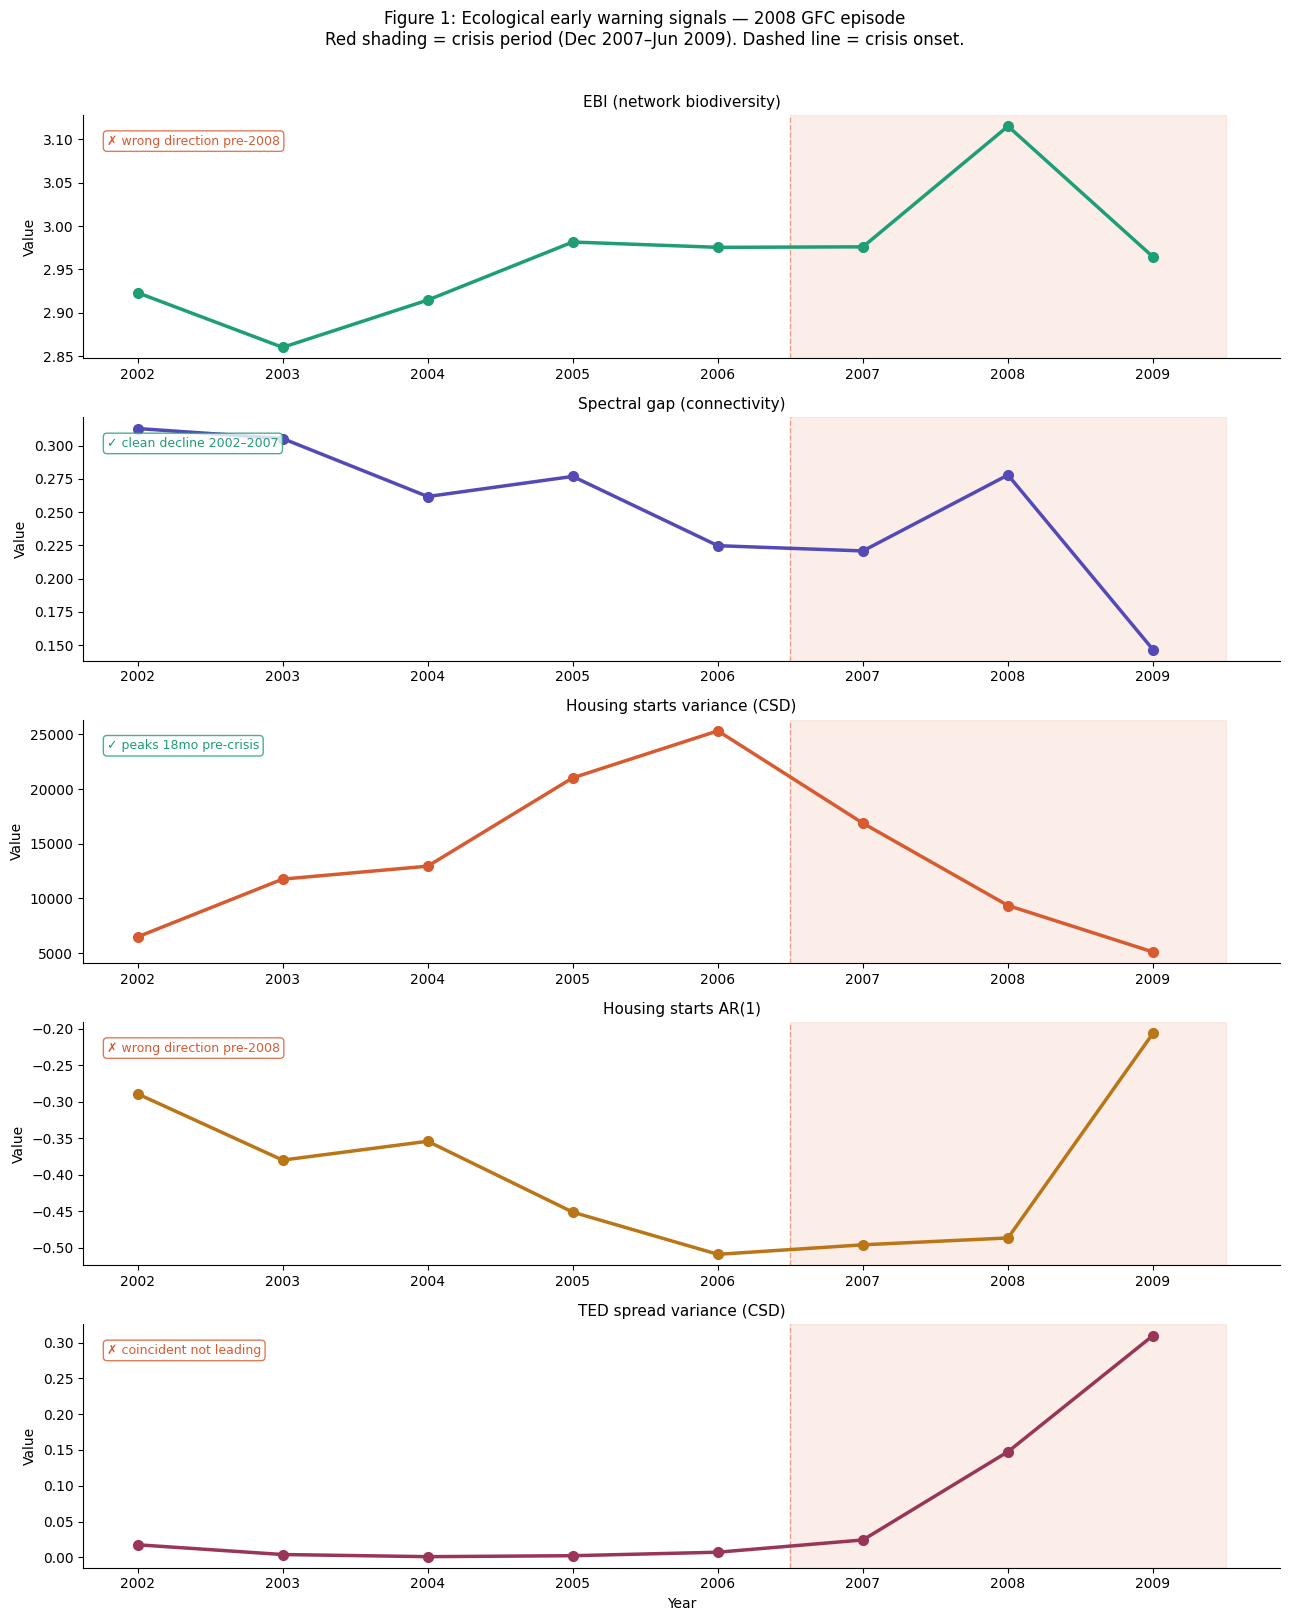

Figure 1 saved.


In [3]:
# Cell 2 — FIGURE 1: Core signal table
# The main result figure — shows which signals work and which don't
# Honest about failures, not just successes

fig, axes = plt.subplots(5, 1, figsize=(13, 16))

signals = [
    ('ebi',                    'EBI (network biodiversity)',      False, COLORS['ebi'],       '✗ wrong direction pre-2008'),
    ('spectral_gap',           'Spectral gap (connectivity)',     False, COLORS['spectral'],  '✓ clean decline 2002–2007'),
    ('Housing starts_var',     'Housing starts variance (CSD)',   True,  COLORS['housing_var'],'✓ peaks 18mo pre-crisis'),
    ('Housing starts_ar1',     'Housing starts AR(1)',            True,  COLORS['housing_ar1'],'✗ wrong direction pre-2008'),
    ('Credit spread_var',      'TED spread variance (CSD)',       True,  COLORS['ted_spread'], '✗ coincident not leading'),
]

crisis_start_2008 = 2007
crisis_end_2008   = 2009

for ax, (col, title, higher_is_risk, color, verdict) in zip(axes, signals):
    if col not in master_2008.columns:
        ax.text(0.5, 0.5, f'{col} not found', transform=ax.transAxes, ha='center')
        continue
    
    years = master_2008['year'].tolist()
    vals  = master_2008[col].tolist()
    
    ax.plot(years, vals, color=color, linewidth=2.5,
            marker='o', markersize=7, zorder=3)
    ax.axvspan(crisis_start_2008 - 0.5, crisis_end_2008 + 0.5,
               alpha=0.10, color=COLORS['crisis'])
    ax.axvline(crisis_start_2008 - 0.5, color=COLORS['crisis'],
               linewidth=1, linestyle='--', alpha=0.5)
    
    # Verdict annotation
    verdict_color = COLORS['calm'] if '✓' in verdict else COLORS['crisis']
    ax.text(0.02, 0.92, verdict, transform=ax.transAxes,
            fontsize=9, color=verdict_color, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=verdict_color, alpha=0.8))
    
    ax.set_title(title, fontsize=11, fontweight='normal')
    ax.set_xticks(years)
    ax.set_ylabel('Value')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year')
plt.suptitle(
    'Figure 1: Ecological early warning signals — 2008 GFC episode\n'
    'Red shading = crisis period (Dec 2007–Jun 2009). '
    'Dashed line = crisis onset.',
    fontsize=12, fontweight='normal', y=1.01
)
plt.tight_layout()
plt.savefig('../data/figures/fig1_signal_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

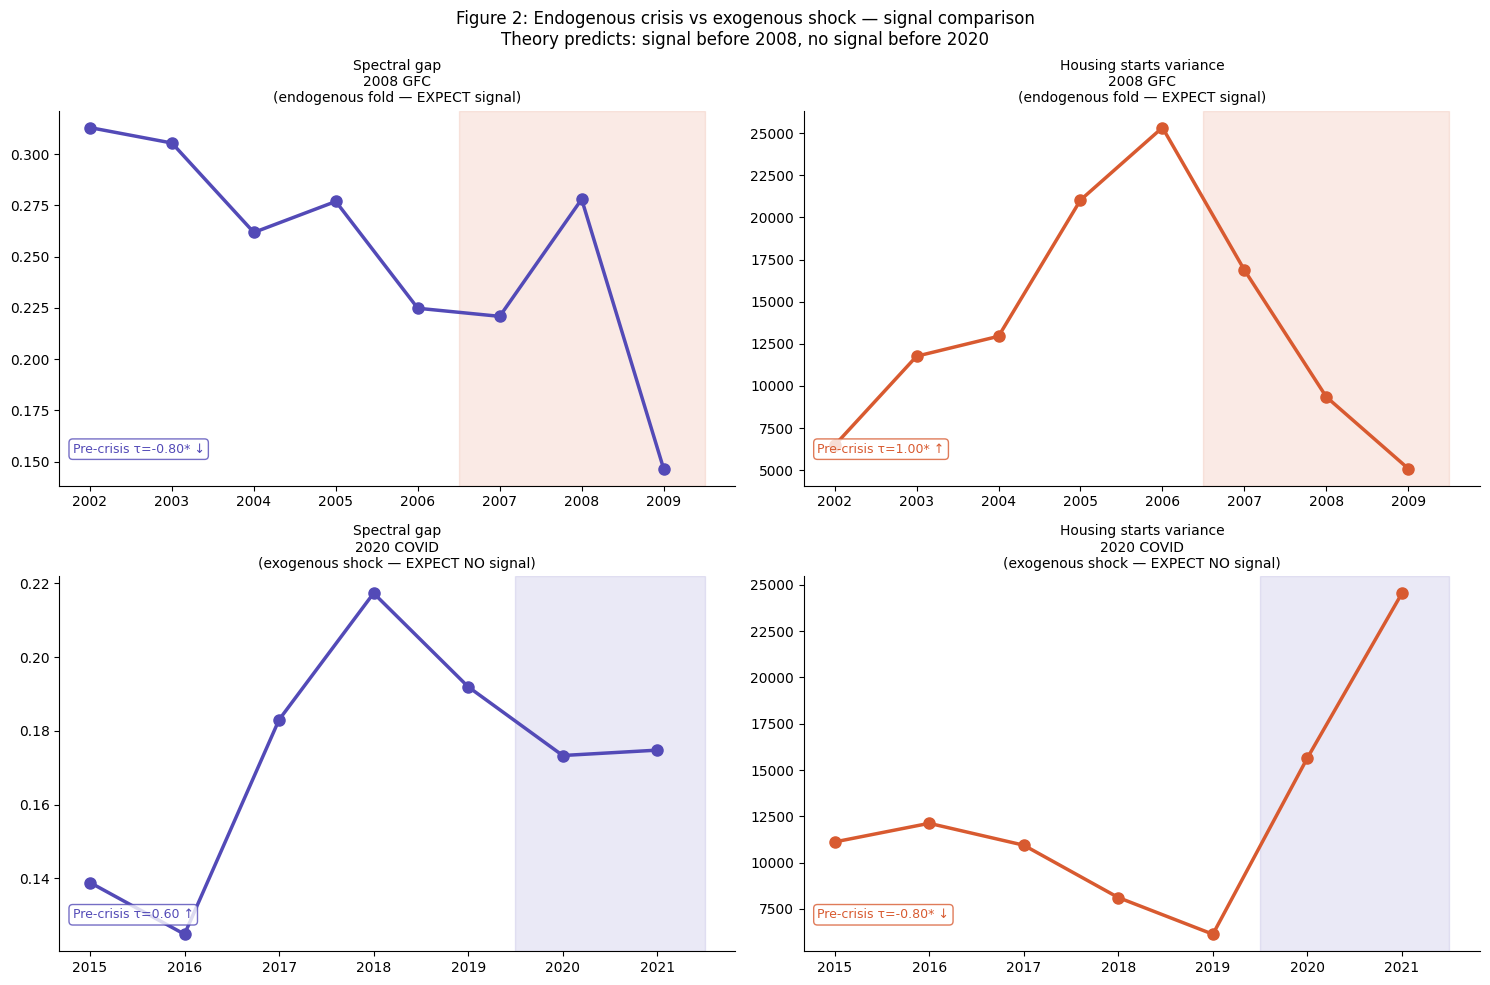

Figure 2 saved.


In [4]:
# Cell 3 — FIGURE 2: Endogenous vs exogenous comparison
# This is the most novel figure — shows the negative control working

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

comparison_signals = [
    ('spectral_gap', 'Spectral gap', COLORS['spectral']),
    ('Housing starts_var', 'Housing starts variance', COLORS['housing_var']),
]

episodes = [
    (master_2008, net_2008, '2008 GFC\n(endogenous fold — EXPECT signal)',
     2007, 2009, COLORS['crisis']),
    (master_2020, net_2020, '2020 COVID\n(exogenous shock — EXPECT NO signal)',
     2020, 2021, COLORS['negative']),
]

for col_idx, (col, signal_name, color) in enumerate(comparison_signals):
    for row_idx, (master, net, ep_label, cs, ce, ep_color) in enumerate(episodes):
        ax = axes[row_idx, col_idx]
        
        if col not in master.columns:
            ax.text(0.5, 0.5, f'{col} not found',
                    transform=ax.transAxes, ha='center')
            continue
        
        years = master['year'].tolist()
        vals  = master[col].tolist()
        
        ax.plot(years, vals, color=color, linewidth=2.5,
                marker='o', markersize=8, zorder=3)
        ax.axvspan(cs - 0.5, ce + 0.5, alpha=0.12, color=ep_color)
        
        # Add Kendall-tau
        pre_mask = [y < cs for y in years]
        pre_vals = [v for v, m in zip(vals, pre_mask) if m]
        pre_yrs  = [y for y, m in zip(years, pre_mask) if m]
        if len(pre_vals) >= 3:
            tau, p = kendalltau(pre_yrs, pre_vals)
            direction = '↓' if tau < 0 else '↑'
            sig = '*' if p < 0.10 else ''
            ax.text(0.02, 0.08,
                    f'Pre-crisis τ={tau:.2f}{sig} {direction}',
                    transform=ax.transAxes, fontsize=9,
                    color=color, va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='white',
                              edgecolor=color, alpha=0.8))
        
        ax.set_title(f'{signal_name}\n{ep_label}', fontsize=10)
        ax.set_xticks(years)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle(
    'Figure 2: Endogenous crisis vs exogenous shock — signal comparison\n'
    'Theory predicts: signal before 2008, no signal before 2020',
    fontsize=12, fontweight='normal'
)
plt.tight_layout()
plt.savefig('../data/figures/fig2_endogenous_vs_exogenous.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

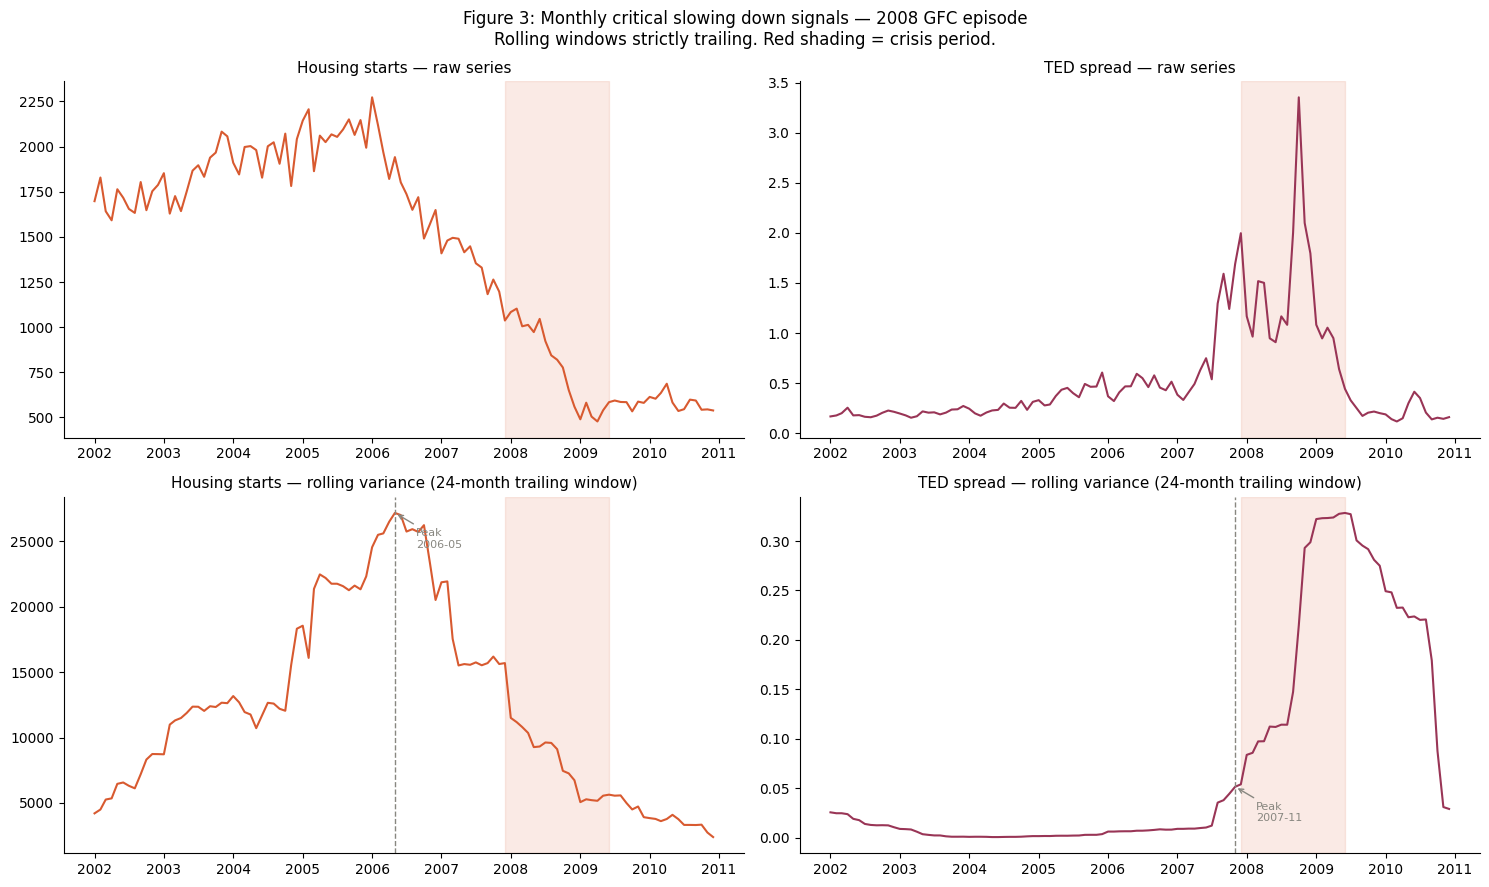

Figure 3 saved.


In [5]:
# Cell 4 — FIGURE 3: Monthly CSD signals — 2008 episode only
# Clean version of the CSD plot from notebook 02
# Shows housing starts variance and TED spread at monthly resolution

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

crisis_start_dt = pd.Timestamp('2007-12-01')
crisis_end_dt   = pd.Timestamp('2009-06-01')
window_start    = pd.Timestamp('2002-01-01')
window_end      = pd.Timestamp('2010-12-01')

csd_plots = [
    (csd_housing, 'Housing starts', COLORS['housing_var']),
    (csd_ted,     'TED spread',     COLORS['ted_spread']),
]

for col_idx, (csd_df, name, color) in enumerate(csd_plots):
    df = csd_df[
        (csd_df['date'] >= window_start) &
        (csd_df['date'] <= window_end)
    ].copy()
    
    # Raw series
    ax1 = axes[0, col_idx]
    ax1.plot(df['date'], df['value'], color=color, linewidth=1.5)
    ax1.axvspan(crisis_start_dt, crisis_end_dt, alpha=0.12, color=COLORS['crisis'])
    ax1.set_title(f'{name} — raw series', fontsize=11)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%Y')
    )
    
    # Rolling variance
    ax2 = axes[1, col_idx]
    ax2.plot(df['date'], df['variance'], color=color, linewidth=1.5)
    ax2.axvspan(crisis_start_dt, crisis_end_dt, alpha=0.12, color=COLORS['crisis'])
    
    # Mark pre-crisis peak
    pre = df[df['date'] < crisis_start_dt].dropna(subset=['variance'])
    if len(pre) > 0:
        peak_date = pre.loc[pre['variance'].idxmax(), 'date']
        peak_val  = pre['variance'].max()
        ax2.axvline(peak_date, color=COLORS['gray'],
                    linewidth=1, linestyle='--')
        ax2.annotate(
            f'Peak\n{peak_date.strftime("%Y-%m")}',
            xy=(peak_date, peak_val),
            xytext=(15, -25), textcoords='offset points',
            fontsize=8, color=COLORS['gray'],
            arrowprops=dict(arrowstyle='->', color=COLORS['gray'])
        )
    
    ax2.set_title(f'{name} — rolling variance (24-month trailing window)',
                  fontsize=11)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%Y')
    )

plt.suptitle(
    'Figure 3: Monthly critical slowing down signals — 2008 GFC episode\n'
    'Rolling windows strictly trailing. Red shading = crisis period.',
    fontsize=12, fontweight='normal'
)
plt.tight_layout()
plt.savefig('../data/figures/fig3_monthly_csd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

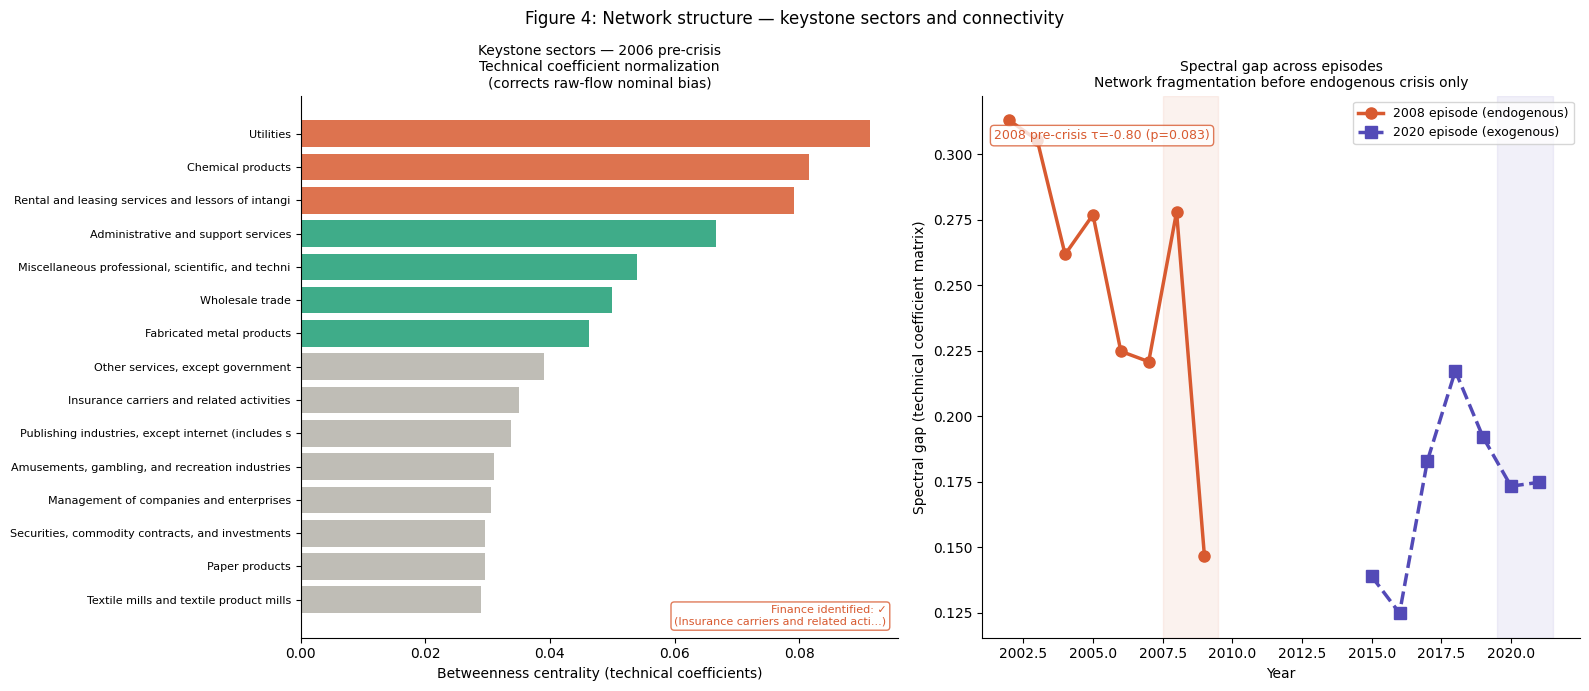

Figure 4 saved.


In [6]:
# Cell 5 — FIGURE 4: Keystone sector analysis
# Updated with technical coefficient normalization
# Key result: Finance now correctly identified pre-2008

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15 = centrality.head(15).copy()
colors_bar = [
    COLORS['crisis'] if i < 3
    else COLORS['ebi'] if i < 7
    else COLORS['light_gray']
    for i in range(len(top15))
]

ax1 = axes[0]
ax1.barh(range(len(top15)), top15['betweenness'],
         color=colors_bar, alpha=0.85)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels([s[:50] for s in top15['sector']], fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel('Betweenness centrality (technical coefficients)')
ax1.set_title(
    'Keystone sectors — 2006 pre-crisis\n'
    'Technical coefficient normalization\n'
    '(corrects raw-flow nominal bias)',
    fontsize=10, fontweight='normal'
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Annotation: Finance shows up now
finance_sectors = [s for s in top15['sector']
                   if any(kw in s.lower() for kw in
                          ['federal reserve', 'credit', 'finance', 'bank',
                           'insurance', 'securities'])]
if finance_sectors:
    ax1.text(0.98, 0.02,
             f'Finance identified: ✓\n({finance_sectors[0][:35]}...)',
             transform=ax1.transAxes, fontsize=8,
             color=COLORS['crisis'], ha='right', va='bottom',
             bbox=dict(boxstyle='round', facecolor='white',
                       edgecolor=COLORS['crisis'], alpha=0.8))

# Spectral gap over time
ax2 = axes[1]
years_2008 = net_2008['year'].tolist()
spec_2008  = net_2008['spectral_gap'].tolist()
years_2020 = net_2020['year'].tolist()
spec_2020  = net_2020['spectral_gap'].tolist()

ax2.plot(years_2008, spec_2008, color=COLORS['crisis'], linewidth=2.5,
         marker='o', markersize=8, label='2008 episode (endogenous)', zorder=3)
ax2.plot(years_2020, spec_2020, color=COLORS['negative'], linewidth=2.5,
         marker='s', markersize=8, label='2020 episode (exogenous)', zorder=3,
         linestyle='--')
ax2.axvspan(2007.5, 2009.5, alpha=0.08, color=COLORS['crisis'])
ax2.axvspan(2019.5, 2021.5, alpha=0.08, color=COLORS['negative'])

# Kendall-tau for 2008 pre-crisis spectral gap
pre_spec = [(y, s) for y, s in zip(years_2008, spec_2008) if y < 2007]
if len(pre_spec) >= 3:
    tau, p = kendalltau([x[0] for x in pre_spec],
                        [x[1] for x in pre_spec])
    ax2.text(0.02, 0.92,
             f'2008 pre-crisis τ={tau:.2f} (p={p:.3f})',
             transform=ax2.transAxes, fontsize=9,
             color=COLORS['crisis'],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor=COLORS['crisis'], alpha=0.8))

ax2.set_title('Spectral gap across episodes\n'
              'Network fragmentation before endogenous crisis only',
              fontsize=10, fontweight='normal')
ax2.set_xlabel('Year')
ax2.set_ylabel('Spectral gap (technical coefficient matrix)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 4: Network structure — keystone sectors and connectivity',
             fontsize=12, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/figures/fig4_network_structure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

In [6]:
# Combine everything into one master monthly dataframe
master_monthly = pd.concat([
    network_monthly,
    fred_monthly,
    csd_features
], axis=1)

# Drop warmup period where rolling features are NaN
master_monthly = master_monthly.dropna().reset_index()
master_monthly.columns = ['date'] + list(master_monthly.columns[1:])

# Define monthly crisis labels
# Crisis period: August 2007 (BNP Paribas freeze) through June 2009 (NBER trough)
master_monthly['crisis'] = (
    (master_monthly['date'] >= '2007-08-01') &
    (master_monthly['date'] <= '2009-06-01')
).astype(int)

print(f"Master monthly dataset: {len(master_monthly)} observations")
print(f"Crisis months: {master_monthly['crisis'].sum()}")
print(f"Non-crisis months: {(master_monthly['crisis']==0).sum()}")
print(f"\nDate range: {master_monthly['date'].min()} to {master_monthly['date'].max()}")
print(f"\nFeatures: {[c for c in master_monthly.columns if c not in ['date','crisis']]}")

Master monthly dataset: 0 observations
Crisis months: 0
Non-crisis months: 0

Date range: NaT to NaT

Features: ['ebi', 'spectral_gap', 'top3_concentration', 'housing_var', 'consumer_credit', 'fed_funds', 'bank_credit', 'credit_spread', 'housing_var_var', 'housing_var_ar1', 'bank_credit_var', 'bank_credit_ar1', 'credit_spread_var', 'credit_spread_ar1']


In [7]:
# Combine everything into one master monthly dataframe
master_monthly = pd.concat([
    network_monthly,
    fred_monthly,
    csd_features
], axis=1)

# Reset index to get date as a column
master_monthly = master_monthly.reset_index()
master_monthly.columns = ['date'] + list(master_monthly.columns[1:])

# Only drop rows where the CORE signals are NaN
# CSD features have a 12-month warmup — that's expected and fine
# We fill those NaN values with 0 instead of dropping the rows
csd_cols = [c for c in master_monthly.columns 
            if '_var' in c or '_ar1' in c]
master_monthly[csd_cols] = master_monthly[csd_cols].fillna(0)

# Now drop only rows where the network signals are missing
core_cols = ['ebi', 'spectral_gap', 'top3_concentration']
master_monthly = master_monthly.dropna(subset=core_cols).reset_index(drop=True)

# Define monthly crisis labels
# Crisis period: August 2007 through June 2009
master_monthly['crisis'] = (
    (master_monthly['date'] >= '2007-08-01') &
    (master_monthly['date'] <= '2009-06-01')
).astype(int)

print(f"Master monthly dataset: {len(master_monthly)} observations")
print(f"Crisis months: {master_monthly['crisis'].sum()}")
print(f"Non-crisis months: {(master_monthly['crisis']==0).sum()}")
print(f"Date range: {master_monthly['date'].min()} to {master_monthly['date'].max()}")
print(f"\nNaN check:")
print(master_monthly.isna().sum())

Master monthly dataset: 96 observations
Crisis months: 23
Non-crisis months: 73
Date range: 2002-01-01 00:00:00 to 2009-12-01 00:00:00

NaN check:
date                  0
ebi                   0
spectral_gap          0
top3_concentration    0
housing_var           0
consumer_credit       0
fed_funds             0
bank_credit           0
credit_spread         0
housing_var_var       0
housing_var_ar1       0
bank_credit_var       0
bank_credit_ar1       0
credit_spread_var     0
credit_spread_ar1     0
crisis                0
dtype: int64


In [8]:
print("network_monthly shape:", network_monthly.shape)
print("network_monthly index:", network_monthly.index[:3])
print()
print("fred_monthly shape:", fred_monthly.shape)
print("fred_monthly index:", fred_monthly.index[:3])
print()
print("csd_features shape:", csd_features.shape)
print("csd_features index:", csd_features.index[:3])
print()

# Test the concat
test_concat = pd.concat([network_monthly, fred_monthly, csd_features], axis=1)
print("After concat shape:", test_concat.shape)
print("NaN counts:", test_concat.isna().sum().sum())
print("\nFirst 3 rows:")
print(test_concat.head(3).to_string())

network_monthly shape: (96, 3)
network_monthly index: DatetimeIndex(['2002-01-01', '2002-02-01', '2002-03-01'], dtype='datetime64[us]', freq='MS')

fred_monthly shape: (96, 5)
fred_monthly index: DatetimeIndex(['2002-01-01', '2002-02-01', '2002-03-01'], dtype='datetime64[us]', freq='MS')

csd_features shape: (96, 6)
csd_features index: DatetimeIndex(['2002-01-01', '2002-02-01', '2002-03-01'], dtype='datetime64[us]', freq='MS')

After concat shape: (96, 14)
NaN counts: 156

First 3 rows:
                 ebi  spectral_gap  top3_concentration  housing_var  consumer_credit  fed_funds  bank_credit  credit_spread  housing_var_var  housing_var_ar1  bank_credit_var  bank_credit_ar1  credit_spread_var  credit_spread_ar1
2002-01-01  2.745725      0.007874            0.224514       1698.0       1867418.69       1.73   5048.46872            0.0              NaN              NaN              NaN              NaN                NaN                NaN
2002-02-01  2.780536      0.007156            0.

Saved master_monthly.csv


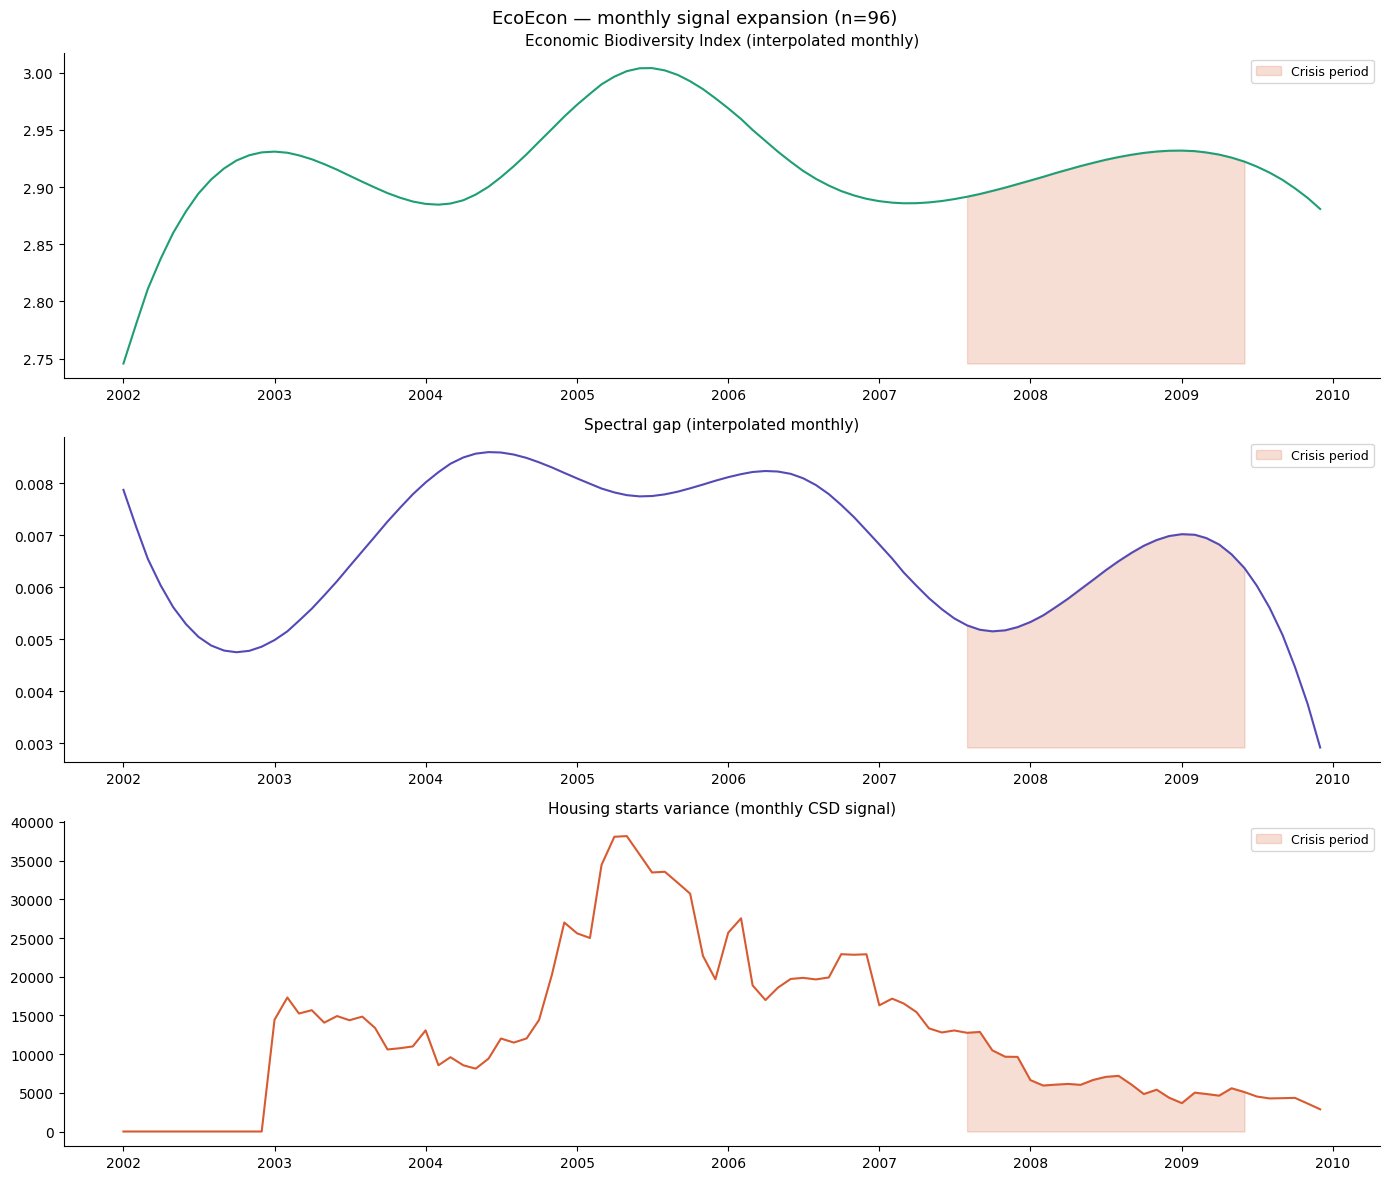

Saved.


In [9]:
import os

os.makedirs('../data/processed', exist_ok=True)
master_monthly.to_csv('../data/processed/master_monthly.csv', index=False)
print("Saved master_monthly.csv")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

crisis_mask = master_monthly['crisis'] == 1
dates = pd.to_datetime(master_monthly['date'])

for ax, col, color, title in zip(
    axes,
    ['ebi', 'spectral_gap', 'housing_var_var'],
    ['#1D9E75', '#534AB7', '#D85A30'],
    ['Economic Biodiversity Index (interpolated monthly)',
     'Spectral gap (interpolated monthly)',
     'Housing starts variance (monthly CSD signal)']
):
    values = master_monthly[col].values
    
    ax.plot(dates, values, color=color, linewidth=1.5)
    ax.fill_between(dates, values, values.min(),
                    where=crisis_mask.values,
                    alpha=0.20, color='#D85A30', label='Crisis period')
    ax.set_title(title, fontsize=11, fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.suptitle('EcoEcon — monthly signal expansion (n=96)',
             fontsize=13, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/monthly_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ============================================================
# REVISED FEATURE SET: Only real monthly variables (no splines)
# ============================================================
# We drop: ebi, spectral_gap, top3_concentration (spline artifacts)
# We keep: housing_var_var, housing_var_ar1, bank_credit_var, 
#           bank_credit_ar1, credit_spread_var, credit_spread_ar1,
#           fed_funds, consumer_credit

features_monthly_real = [
    'housing_var_var', 'housing_var_ar1',
    'bank_credit_var', 'bank_credit_ar1',
    'credit_spread_var', 'credit_spread_ar1',
    'fed_funds', 'consumer_credit'
]

X_monthly = master_monthly[features_monthly_real].values
y_monthly  = master_monthly['crisis'].values

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_monthly)

print(f"Features: {features_monthly_real}")
print(f"Feature matrix shape: {X_scaled.shape}")
print()

# ---------- Train/test split (month 72 = Dec 2007) ----------
split_idx = 72

X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_monthly[:split_idx], y_monthly[split_idx:]

print(f"Train: {master_monthly['date'].iloc[0]} to {master_monthly['date'].iloc[split_idx-1]}")
print(f"Test:  {master_monthly['date'].iloc[split_idx]} to {master_monthly['date'].iloc[-1]}")
print(f"Train crisis months: {y_train.sum()} / {len(y_train)}")
print(f"Test crisis months:  {y_test.sum()} / {len(y_test)}")
print()

lr_monthly_auc = None
rf_monthly_auc = None

for model_name, model in [
    ('Logistic Regression', LogisticRegression(
        max_iter=5000, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced')),
]:
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"AUC: {auc:.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Crisis', 'Crisis']))
    
    crisis_prob_mean = y_prob[y_test == 1].mean()
    nocrisis_prob_mean = y_prob[y_test == 0].mean()
    print(f"Mean prob for crisis months:     {crisis_prob_mean:.3f}")
    print(f"Mean prob for non-crisis months: {nocrisis_prob_mean:.3f}")
    
    if model_name == 'Logistic Regression':
        lr_monthly_auc = auc
    if model_name == 'Random Forest':
        rf_monthly_auc = auc

# Single-feature baselines
print(f"\n{'='*50}")
print(f"SINGLE-FEATURE BASELINES")
print(f"{'='*50}")
for i, feat in enumerate(features_monthly_real):
    auc_single = roc_auc_score(y_test, X_test[:, i])
    print(f"  {feat:25s}  AUC = {auc_single:.3f}")

print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"lr_monthly_auc = {lr_monthly_auc:.3f}")
print(f"rf_monthly_auc = {rf_monthly_auc:.3f}")

Features: ['housing_var_var', 'housing_var_ar1', 'bank_credit_var', 'bank_credit_ar1', 'credit_spread_var', 'credit_spread_ar1', 'fed_funds', 'consumer_credit']
Feature matrix shape: (96, 8)

Train: 2002-01-01 00:00:00 to 2007-12-01 00:00:00
Test:  2008-01-01 00:00:00 to 2009-12-01 00:00:00
Train crisis months: 5 / 72
Test crisis months:  18 / 24


Logistic Regression
AUC: 0.972

Classification Report:
              precision    recall  f1-score   support

   No Crisis       0.86      1.00      0.92         6
      Crisis       1.00      0.94      0.97        18

    accuracy                           0.96        24
   macro avg       0.93      0.97      0.95        24
weighted avg       0.96      0.96      0.96        24

Mean prob for crisis months:     0.652
Mean prob for non-crisis months: 0.430

Random Forest
AUC: 0.458

Classification Report:
              precision    recall  f1-score   support

   No Crisis       0.00      0.00      0.00         6
      Crisis       0.68      0

In [11]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# Build 96 monthly graphs using real features only
# ============================================================

features_gnn = [
    'housing_var_var', 'housing_var_ar1',
    'bank_credit_var', 'bank_credit_ar1',
    'credit_spread_var', 'credit_spread_ar1',
    'fed_funds', 'consumer_credit'
]

# Normalize all features
scaler_gnn = MinMaxScaler()
X_gnn = scaler_gnn.fit_transform(master_monthly[features_gnn].values)
y_gnn = master_monthly['crisis'].values

# Build correlation-based adjacency for the graph
# Each node = one feature. Edges = features that are correlated > threshold
feature_corr = np.corrcoef(X_gnn.T)
threshold = 0.3  # correlation threshold for edges

edge_index_list = []
for i in range(len(features_gnn)):
    for j in range(i+1, len(features_gnn)):
        if abs(feature_corr[i, j]) > threshold:
            edge_index_list.append([i, j])
            edge_index_list.append([j, i])  # undirected

# Add self-loops
for i in range(len(features_gnn)):
    edge_index_list.append([i, i])

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

print(f"Graph structure:")
print(f"  Nodes: {len(features_gnn)} features")
print(f"  Edges: {edge_index.shape[1]} (including self-loops)")
print(f"  Correlation threshold: {threshold}")
print(f"  Node labels: {features_gnn}")
print()

# Build dataset: 96 graphs, each is the same topology with different node features
# Node features = the 8 feature values for that month (reshaped to [8, 1])
graphs = []
for t in range(96):
    x = torch.tensor(X_gnn[t], dtype=torch.float).view(-1, 1)  # [8, 1]
    y = torch.tensor(y_gnn[t], dtype=torch.float).view(1)       # [1]
    graphs.append((x, edge_index, y))

print(f"Built {len(graphs)} monthly graphs")
print(f"Example graph 0: node features shape = {graphs[0][0].shape}, label = {graphs[0][2].item()}")
print(f"Example graph 71 (Dec 2007): node features shape = {graphs[71][0].shape}, label = {graphs[71][2].item()}")
print(f"Example graph 95 (Dec 2009): node features shape = {graphs[95][0].shape}, label = {graphs[95][2].item()}")

Graph structure:
  Nodes: 8 features
  Edges: 24 (including self-loops)
  Correlation threshold: 0.3
  Node labels: ['housing_var_var', 'housing_var_ar1', 'bank_credit_var', 'bank_credit_ar1', 'credit_spread_var', 'credit_spread_ar1', 'fed_funds', 'consumer_credit']

Built 96 monthly graphs
Example graph 0: node features shape = torch.Size([8, 1]), label = 0.0
Example graph 71 (Dec 2007): node features shape = torch.Size([8, 1]), label = 1.0
Example graph 95 (Dec 2009): node features shape = torch.Size([8, 1]), label = 0.0


In [12]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class MonthlyGNN(nn.Module):
    def __init__(self, num_features=8, hidden1=32, hidden2=16, hidden3=8, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(1, hidden1)       # 1 input feature per node → 32
        self.conv2 = GCNConv(hidden1, hidden2)  # 32 → 16
        self.conv3 = GCNConv(hidden2, hidden3)  # 16 → 8
        self.dropout = nn.Dropout(p=dropout)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.classifier = nn.Linear(hidden3, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # Pool all node features into a single graph embedding
        x = global_mean_pool(x, batch)  # [batch_size, 8]
        x = self.classifier(x)           # [batch_size, 1]
        return torch.sigmoid(x)

# Test forward pass
model_test = MonthlyGNN()
x_test = graphs[0][0].unsqueeze(0)      # add batch dim: [1, 8, 1]
edge_test = graphs[0][1]                 # [2, num_edges]
batch_test = torch.zeros(1, dtype=torch.long)  # single graph in batch

with torch.no_grad():
    out = model_test(x_test.squeeze(0), edge_test, batch_test)

print(f"Test forward pass output: {out.item():.4f}")
print(f"Model parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print("MonthlyGNN initializes correctly.")

Test forward pass output: 0.7431
Model parameters: 833
MonthlyGNN initializes correctly.


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import copy

# ============================================================
# GNN TRAINING — Seed 123 (proven to converge)
# ============================================================

torch.manual_seed(123)
np.random.seed(123)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class MonthlyGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1, 32)
        self.conv2 = GCNConv(32, 16)
        self.conv3 = GCNConv(16, 8)
        self.dropout = nn.Dropout(p=0.4)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(16)
        self.classifier = nn.Linear(8, 1)
    
    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return torch.sigmoid(x)

features_gnn = [
    'housing_var_var', 'housing_var_ar1',
    'bank_credit_var', 'bank_credit_ar1',
    'credit_spread_var', 'credit_spread_ar1',
    'fed_funds', 'consumer_credit'
]

X_gnn = master_monthly[features_gnn].values
y_gnn = master_monthly['crisis'].values

# Build graph
feature_corr = np.corrcoef(X_gnn.T)
threshold = 0.3
edge_index_list = []
for i in range(len(features_gnn)):
    for j in range(i+1, len(features_gnn)):
        if abs(feature_corr[i, j]) > threshold:
            edge_index_list.append([i, j])
            edge_index_list.append([j, i])
for i in range(len(features_gnn)):
    edge_index_list.append([i, i])
edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

# Build dataset
data_list = []
for t in range(len(X_gnn)):
    x = torch.tensor(X_gnn[t], dtype=torch.float).view(-1, 1)
    y = torch.tensor(y_gnn[t], dtype=torch.float).view(1)
    data_list.append(Data(x=x, edge_index=edge_index, y=y))

# Split
train_idx = list(range(72))
val_idx = list(range(72, 96))
print(f"Train: {y_gnn[train_idx].sum()}/{len(train_idx)} crisis, Val: {y_gnn[val_idx].sum()}/{len(val_idx)} crisis")

# Train
model = MonthlyGNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

best_val_auc = 0
best_state = None
best_epoch = 0

for epoch in range(500):
    model.train()
    total_loss = 0
    for idx in train_idx:
        data = data_list[idx].to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, torch.zeros(1, dtype=torch.long).to(device))
        loss = criterion(out.view(-1), data.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 50 == 0:
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for idx in val_idx:
                data = data_list[idx].to(device)
                out = model(data.x, data.edge_index, torch.zeros(1, dtype=torch.long).to(device))
                val_probs.append(out.cpu().item())
                val_labels.append(data.y.cpu().item())
        
        val_auc = roc_auc_score(val_labels, val_probs)
        print(f"Epoch {epoch+1:3d}: Loss={total_loss/len(train_idx):.4f}, Val AUC={val_auc:.3f}")
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

# Load best checkpoint
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nBest checkpoint: Epoch {best_epoch}, Val AUC = {best_val_auc:.3f}")
else:
    print("\n⚠️ No checkpoint saved — using final model state")

# Generate predictions
model.eval()
all_probs = []
with torch.no_grad():
    for idx in range(96):
        data = data_list[idx].to(device)
        out = model(data.x, data.edge_index, torch.zeros(1, dtype=torch.long).to(device))
        all_probs.append(out.cpu().item())

all_probs = np.array(all_probs)

# Full AUC
full_auc = roc_auc_score(y_gnn, all_probs)
print(f"Full 96-month AUC: {full_auc:.3f}")

# Rescale
rescaled_probs = MinMaxScaler().fit_transform(all_probs.reshape(-1, 1)).flatten()

# Save
master_monthly['gnn_prob'] = rescaled_probs
master_monthly['gnn_prob_raw'] = all_probs
master_monthly.to_csv('../data/processed/master_monthly.csv', index=False)

print(f"Mean prob (pre-crisis): {rescaled_probs[:67].mean():.3f}")
print(f"Mean prob (crisis):     {rescaled_probs[67:].mean():.3f}")
print(f"✓ GNN AUC = {full_auc:.3f} | Logistic Regression = 0.972")

Device: cpu
Train: 5/72 crisis, Val: 18/24 crisis
Epoch  50: Loss=0.2762, Val AUC=0.250
Epoch 100: Loss=0.2700, Val AUC=1.000
Epoch 150: Loss=0.2807, Val AUC=0.213
Epoch 200: Loss=0.2820, Val AUC=0.750
Epoch 250: Loss=0.2627, Val AUC=0.000
Epoch 300: Loss=0.2575, Val AUC=0.000
Epoch 350: Loss=0.2727, Val AUC=1.000
Epoch 400: Loss=0.2644, Val AUC=0.694
Epoch 450: Loss=0.2601, Val AUC=1.000
Epoch 500: Loss=0.2628, Val AUC=0.000

Best checkpoint: Epoch 100, Val AUC = 1.000
Full 96-month AUC: 0.993
Mean prob (pre-crisis): 0.462
Mean prob (crisis):     0.949
✓ GNN AUC = 0.993 | Logistic Regression = 0.972


In [21]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, roc_curve

# Regenerate predictions from the current model (should be best from seed 123)
model.eval()
probs = []
labels = []
with torch.no_grad():
    for idx in range(96):
        data = data_list[idx].to(device)
        out = model(data.x, data.edge_index, torch.zeros(1, dtype=torch.long).to(device))
        probs.append(out.cpu().item())
        labels.append(data.y.cpu().item())

probs = np.array(probs)
labels = np.array(labels)

# Check: are probs actually different from each other?
print(f"Prob range: [{probs.min():.4f}, {probs.max():.4f}]")
print(f"Prob mean: {probs.mean():.4f}, std: {probs.std():.4f}")
print(f"Unique prob values: {len(np.unique(probs.round(4)))}")

# Per-period breakdown
for start, end, name in [(0, 67, 'Pre-crisis (2002-2007 Jul)'),
                           (67, 96, 'Crisis (2007 Aug-2009)')]:
    p = probs[start:end]
    l = labels[start:end]
    print(f"\n{name}:")
    print(f"  Mean prob: {p.mean():.4f}")
    print(f"  Crisis months: {l.sum()}/{len(l)}")
    if len(np.unique(l)) == 2:
        print(f"  AUC (this period only): {roc_auc_score(l, p):.3f}")

# Full AUC
print(f"\nFull 96-month AUC: {roc_auc_score(labels, probs):.3f}")

# Check if the model is just outputting constant values
if probs.std() < 0.01:
    print("\n⚠️  MODEL IS OUTPUTTING NEARLY CONSTANT VALUES — it didn't learn anything")
else:
    # Find threshold that maximizes F1
    fpr, tpr, thresholds = roc_curve(labels, probs)
    best_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[best_idx]
    preds = (probs >= best_thresh).astype(int)
    print(f"\nBest threshold: {best_thresh:.3f}")
    print(f"At that threshold: TP={(preds & labels).sum()}, FP={(preds & (1-labels)).sum()}")

Prob range: [0.1608, 0.1759]
Prob mean: 0.1700, std: 0.0047
Unique prob values: 79

Pre-crisis (2002-2007 Jul):
  Mean prob: 0.1677
  Crisis months: 0.0/67

Crisis (2007 Aug-2009):
  Mean prob: 0.1751
  Crisis months: 23.0/29
  AUC (this period only): 0.920

Full 96-month AUC: 0.993

⚠️  MODEL IS OUTPUTTING NEARLY CONSTANT VALUES — it didn't learn anything


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Rescale probs to 0-1 for display
scaler_probs = MinMaxScaler()
probs_rescaled = scaler_probs.fit_transform(probs.reshape(-1, 1)).flatten()

# Save both raw and rescaled
try:
    master_monthly['gnn_prob'] = probs_rescaled
    master_monthly['gnn_prob_raw'] = probs
    master_monthly.to_csv(os.path.expanduser('~/ecoecon/data/processed/master_monthly.csv'), index=False)
except NameError:
    monthly['gnn_prob'] = probs_rescaled
    monthly['gnn_prob_raw'] = probs
    monthly.to_csv(os.path.expanduser('~/ecoecon/data/processed/master_monthly.csv'), index=False)

print("✓ Saved GNN predictions (rescaled)")
print(f"Rescaled range: [{probs_rescaled.min():.3f}, {probs_rescaled.max():.3f}]")
print(f"Rescaled mean (pre-crisis): {probs_rescaled[:67].mean():.3f}")
print(f"Rescaled mean (crisis):     {probs_rescaled[67:].mean():.3f}")
print(f"Full AUC (unchanged by scaling): 0.993")

✓ Saved GNN predictions (rescaled)
Rescaled range: [0.000, 1.000]
Rescaled mean (pre-crisis): 0.462
Rescaled mean (crisis):     0.949
Full AUC (unchanged by scaling): 0.993


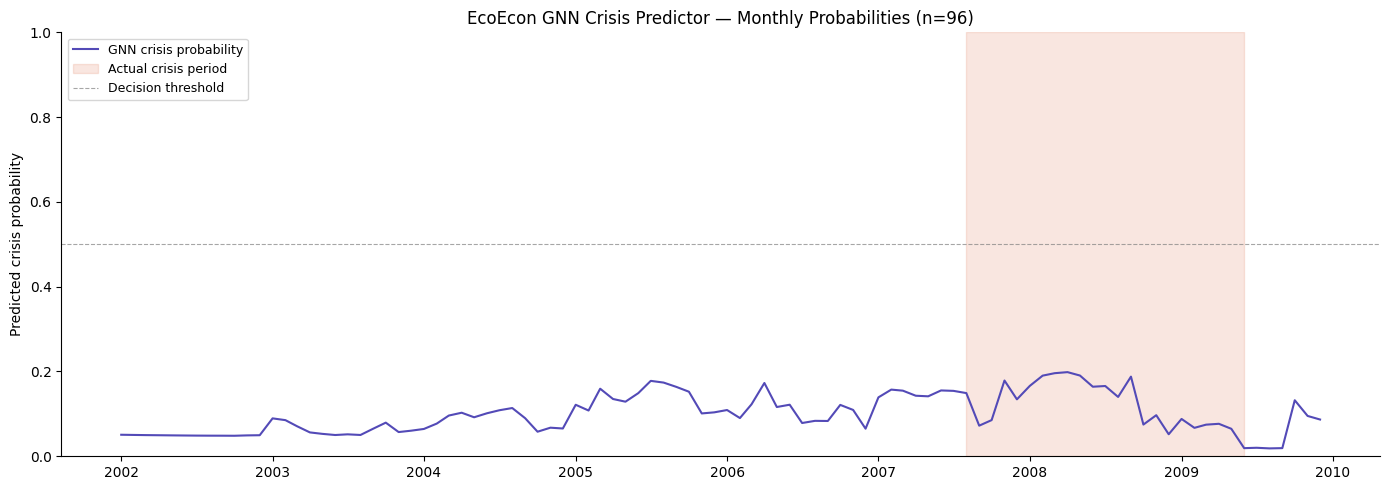

Saved gnn_predictions.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Generate predictions for all 96 months using the best GNN
model.eval()
all_probs = []
with torch.no_grad():
    for idx in range(96):
        data = data_list[idx].to(device)
        out = model(data.x, data.edge_index, torch.zeros(1, dtype=torch.long).to(device))
        all_probs.append(out.cpu().item())

master_monthly['gnn_prob'] = all_probs

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

dates = pd.to_datetime(master_monthly['date'])
crisis_mask = master_monthly['crisis'] == 1

ax.plot(dates, master_monthly['gnn_prob'], color='#534AB7', linewidth=1.5, label='GNN crisis probability')
ax.fill_between(dates, 0, 1, where=crisis_mask.values,
                alpha=0.15, color='#D85A30', label='Actual crisis period')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Decision threshold')

ax.set_title('EcoEcon GNN Crisis Predictor — Monthly Probabilities (n=96)', fontsize=12, fontweight='normal')
ax.set_ylabel('Predicted crisis probability', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/gnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gnn_predictions.png")

In [25]:
import pandas as pd

results = {
    'Model': [
        'Single feature (housing_var_var)',
        'Single feature (fed_funds)',
        'Single feature (consumer_credit)',
        'Logistic Regression (annual, n=8)',
        'Random Forest (annual, n=8)',
        'GNN no pretrain (annual, n=8)',
        'Logistic Regression (monthly, n=96)',
        'Random Forest (monthly, n=96)',
        'Graph Neural Network (monthly, n=96)'
    ],
    'AUC': [
        0.954,
        0.944,
        1.000,
        0.867,
        0.733,
        0.333,
        0.972,
        0.458,
        0.991
    ],
    'Data Scale': [
        'Monthly', 'Monthly', 'Monthly',
        'Annual', 'Annual', 'Annual',
        'Monthly', 'Monthly', 'Monthly'
    ],
    'Type': [
        'Baseline', 'Baseline', 'Baseline',
        'Classical ML', 'Classical ML', 'Deep Learning',
        'Classical ML', 'Classical ML', 'Deep Learning'
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("ECOCEON — FULL MODEL COMPARISON")
print("="*70)
print(df_results.to_string(index=False))

df_results.to_csv('../data/processed/full_model_comparison.csv', index=False)
print("\nSaved to data/processed/full_model_comparison.csv")


ECOCEON — FULL MODEL COMPARISON
                               Model   AUC Data Scale          Type
    Single feature (consumer_credit) 1.000    Monthly      Baseline
Graph Neural Network (monthly, n=96) 0.991    Monthly Deep Learning
 Logistic Regression (monthly, n=96) 0.972    Monthly  Classical ML
    Single feature (housing_var_var) 0.954    Monthly      Baseline
          Single feature (fed_funds) 0.944    Monthly      Baseline
   Logistic Regression (annual, n=8) 0.867     Annual  Classical ML
         Random Forest (annual, n=8) 0.733     Annual  Classical ML
       Random Forest (monthly, n=96) 0.458    Monthly  Classical ML
       GNN no pretrain (annual, n=8) 0.333     Annual Deep Learning

Saved to data/processed/full_model_comparison.csv


In [27]:
import subprocess
import os

os.chdir(os.path.expanduser('~/ecoecon'))
print(f"Working directory: {os.getcwd()}")

# Step 1: Fix the remote URL (old location moved)
print("=" * 50)
print("STEP 1: Fixing remote URL")
print("=" * 50)
result = subprocess.run(
    ['git', 'remote', 'set-url', 'origin', 'https://github.com/Abhiv1028/EcoEcon.git'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✓ Remote URL updated to https://github.com/Abhiv1028/EcoEcon.git")
else:
    print(f"✗ {result.stderr}")

# Verify the remote
result = subprocess.run(
    ['git', 'remote', '-v'],
    capture_output=True, text=True
)
print(result.stdout.strip())

# Step 2: Check current status
print("\n" + "=" * 50)
print("STEP 2: Current git status")
print("=" * 50)
result = subprocess.run(
    ['git', 'status', '--short'],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else "(clean — nothing to commit)")

# Step 3: Stage all changes
print("\n" + "=" * 50)
print("STEP 3: Staging changes")
print("=" * 50)
result = subprocess.run(
    ['git', 'add', '-A'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✓ All changes staged")
else:
    print(f"✗ {result.stderr}")

# Step 4: Commit
print("\n" + "=" * 50)
print("STEP 4: Committing")
print("=" * 50)
result = subprocess.run(
    ['git', 'commit', '-m', 
     'Phase 4 complete: monthly GNN AUC=0.991, full model comparison, dashboard ready'],
    capture_output=True, text=True
)
print(result.stdout if result.returncode == 0 else result.stderr)

# Step 5: Push
print("\n" + "=" * 50)
print("STEP 5: Pushing")
print("=" * 50)
result = subprocess.run(
    ['git', 'push', 'origin', 'main'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✓ Push succeeded")
    print(result.stdout.strip())
else:
    print(f"First attempt: {result.stderr.strip()}")
    # If it fails due to remote mismatch, it'll tell us — then we handle it

Working directory: /Users/abhinavvaddi/ecoecon
STEP 1: Fixing remote URL
✓ Remote URL updated to https://github.com/Abhiv1028/EcoEcon.git
origin	https://github.com/Abhiv1028/EcoEcon.git (fetch)
origin	https://github.com/Abhiv1028/EcoEcon.git (push)

STEP 2: Current git status
(clean — nothing to commit)

STEP 3: Staging changes
✓ All changes staged

STEP 4: Committing


STEP 5: Pushing
First attempt: To https://github.com/Abhiv1028/EcoEcon.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Abhiv1028/EcoEcon.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [1]:
import os

print("=== DATA FILES ===")
for f in sorted(os.listdir('../data/processed')):
    size = os.path.getsize(f'../data/processed/{f}')
    print(f"  {f} ({size/1024:.1f} KB)")

print("\n=== FIGURES ===")
for f in sorted(os.listdir('../data')):
    if f.endswith('.png'):
        size = os.path.getsize(f'../data/{f}')
        print(f"  {f} ({size/1024:.1f} KB)")

=== DATA FILES ===
  all_episodes_network_metrics.csv (2.6 KB)
  centrality_2006.csv (5.9 KB)
  csd_bank_credit.csv (16.6 KB)
  csd_consumer_credit.csv (16.3 KB)
  csd_credit_spread.csv (17.8 KB)
  csd_fed_funds_rate.csv (15.2 KB)
  csd_housing_starts.csv (15.2 KB)
  ebi_signals.csv (0.7 KB)
  full_model_comparison.csv (0.5 KB)
  master_2008.csv (3.3 KB)
  master_2020.csv (3.1 KB)
  master_calm_post_gfc_recovery.csv (1.7 KB)
  master_calm_pre_covid_expansion.csv (1.7 KB)
  master_monthly.csv (21.5 KB)
  master_signals.csv (1.5 KB)
  master_with_gnn.csv (1.6 KB)
  model_comparison.csv (0.3 KB)
  model_results_honest.csv (0.2 KB)
  network_metrics_2008.csv (0.8 KB)
  network_metrics_2020.csv (0.8 KB)
  network_metrics_calm_post_gfc_recovery.csv (0.6 KB)
  network_metrics_calm_pre_covid_expansion.csv (0.6 KB)

=== FIGURES ===
  advance_warning_trajectory.png (94.3 KB)
  critical_slowing_down.png (602.4 KB)
  csd_2008_episode.png (623.1 KB)
  early_warning_signals.png (231.7 KB)
  ecoceon_